# Entrenamiento de Redes Neuronales

En este notebook implementamos:
1. **Perceptrón simple** con dataset linealmente separable
2. **Perceptrón en espiral** (para demostrar que falla)
3. **MLP multicapa** que resuelve el espiral

Todo desde cero, solo con NumPy y Matplotlib.

## 0. Importaciones

In [49]:
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['figure.dpi'] = 100

---
## 1. Perceptrón Simple — Clasificación Lineal

Una sola neurona con sigmoide puede separar datos que son **linealmente separables**.
Generamos dos nubes de puntos centradas en posiciones distintas.

$$y = \sigma(x_1 w_1 + x_2 w_2 + b)$$
$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

### 1.1 Generar dataset sintético linealmente separable

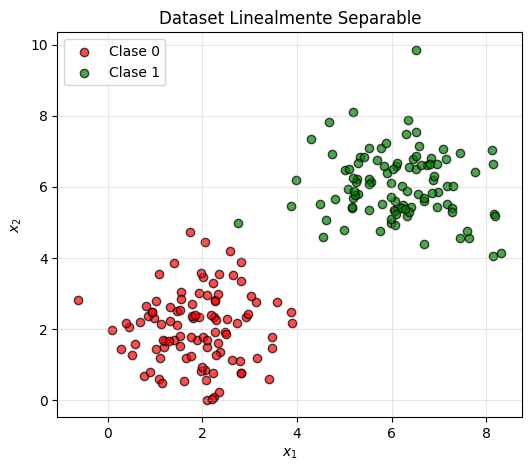

Tamaño del dataset: 200 muestras
Clase 0: 100 | Clase 1: 100


In [51]:
np.random.seed(42)
n = 100

# Clase 0: centrada en (2, 2)
X0 = np.random.randn(n, 2) + np.array([2, 2])
# Clase 1: centrada en (6, 6)
X1 = np.random.randn(n, 2) + np.array([6, 6])

X_lin = np.vstack([X0, X1])
y_lin = np.concatenate([np.zeros(n), np.ones(n)])

# Mezclar datos
idx = np.random.permutation(len(y_lin))
X_lin, y_lin = X_lin[idx], y_lin[idx]

# Visualizar
plt.figure(figsize=(6, 5))
plt.scatter(X_lin[y_lin == 0, 0], X_lin[y_lin == 0, 1], c='red', label='Clase 0', edgecolors='k', alpha=0.7)
plt.scatter(X_lin[y_lin == 1, 0], X_lin[y_lin == 1, 1], c='green', label='Clase 1', edgecolors='k', alpha=0.7)
plt.title('Dataset Linealmente Separable')
plt.xlabel('$x_1$')
plt.ylabel('$x_2$')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Tamaño del dataset: {len(y_lin)} muestras")
print(f"Clase 0: {np.sum(y_lin == 0):.0f} | Clase 1: {np.sum(y_lin == 1):.0f}")

### 1.2 Implementar el Perceptrón

Componentes clave:
- **Forward**: calcular $z = Xw + b$, luego $\hat{y} = \sigma(z)$
- **Loss**: Binary Cross-Entropy $L = -\frac{1}{N}\sum[y\log(\hat{y}) + (1-y)\log(1-\hat{y})]$
- **Backward**: calcular gradientes $\frac{\partial L}{\partial w}$ y $\frac{\partial L}{\partial b}$
- **Update**: $w := w - \alpha \cdot \nabla w$

In [53]:
class Perceptron:
    def __init__(self, n_features, lr=0.1):
        self.w = np.random.randn(n_features) * 0.01
        self.b = 0.0
        self.lr = lr
        self.losses = []

    def sigmoid(self, z):
        z = np.clip(z, -500, 500)
        return 1 / (1 + np.exp(-z))

    def predict(self, X):
        z = X @ self.w + self.b
        return self.sigmoid(z)

    def train(self, X, y, epochs=200):
        for epoch in range(epochs):
            # --- FORWARD ---
            pred = self.predict(X)

            # --- LOSS (Binary Cross-Entropy) ---
            eps = 1e-8
            loss = -np.mean(y * np.log(pred + eps) + (1 - y) * np.log(1 - pred + eps))
            self.losses.append(loss)

            # --- BACKWARD (Gradientes) ---
            error = pred - y                    # (N,)
            dw = X.T @ error / len(y)           # (2,)
            db = np.mean(error)                  # escalar

            # --- UPDATE (Descenso de gradiente) ---
            self.w -= self.lr * dw
            self.b -= self.lr * db

            if epoch % 50 == 0:
                acc = np.mean((pred > 0.5) == y) * 100
                print(f"Epoch {epoch:3d} | Loss: {loss:.4f} | Accuracy: {acc:.1f}%")

        # Resultado final
        pred = self.predict(X)
        acc = np.mean((pred > 0.5) == y) * 100
        print(f"\n>>> Resultado final | Loss: {self.losses[-1]:.4f} | Accuracy: {acc:.1f}%")

### 1.3 Entrenar el Perceptrón

In [55]:
model_lin = Perceptron(n_features=2, lr=0.5)
model_lin.train(X_lin, y_lin, epochs=300)

Epoch   0 | Loss: 0.7053 | Accuracy: 50.0%
Epoch  50 | Loss: 0.1807 | Accuracy: 100.0%
Epoch 100 | Loss: 0.1134 | Accuracy: 100.0%
Epoch 150 | Loss: 0.0851 | Accuracy: 100.0%
Epoch 200 | Loss: 0.0693 | Accuracy: 99.5%
Epoch 250 | Loss: 0.0592 | Accuracy: 99.5%

>>> Resultado final | Loss: 0.0523 | Accuracy: 99.5%


### 1.4 Visualizar resultados

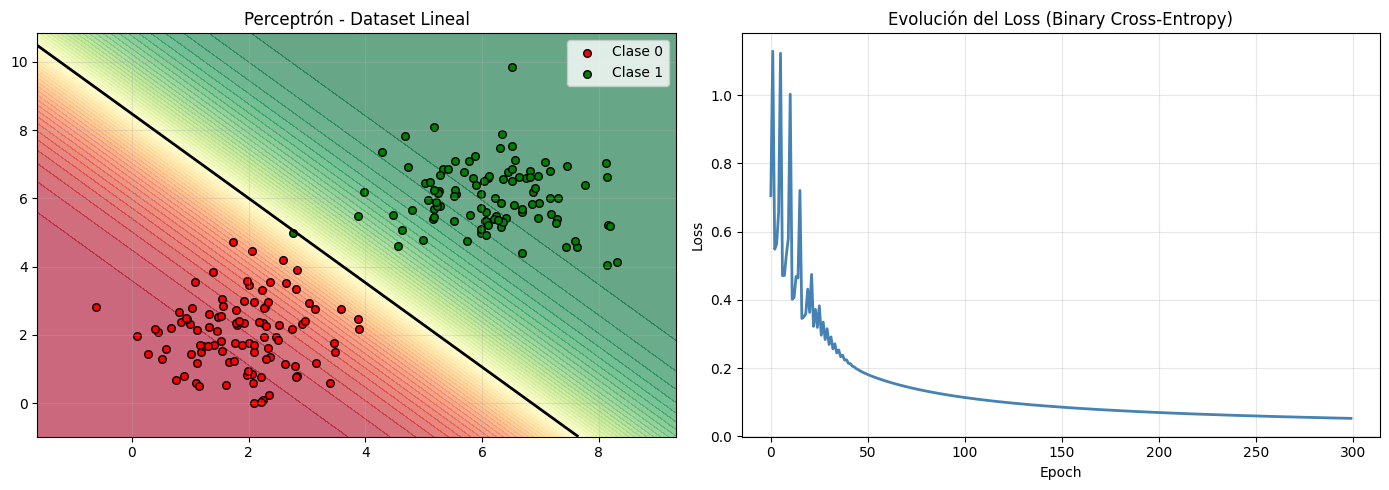

In [57]:
def plot_decision_boundary(model, X, y, title="Frontera de decisión"):
    """Dibuja la frontera de decisión y la curva de loss."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # --- Frontera de decisión ---
    ax = axes[0]
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                          np.linspace(y_min, y_max, 300))
    grid = np.c_[xx.ravel(), yy.ravel()]
    zz = model.predict(grid).reshape(xx.shape)

    ax.contourf(xx, yy, zz, levels=50, cmap='RdYlGn', alpha=0.6)
    ax.contour(xx, yy, zz, levels=[0.5], colors='black', linewidths=2)
    ax.scatter(X[y == 0, 0], X[y == 0, 1], c='red', label='Clase 0', edgecolors='k', s=30)
    ax.scatter(X[y == 1, 0], X[y == 1, 1], c='green', label='Clase 1', edgecolors='k', s=30)
    ax.set_title(title)
    ax.legend()
    ax.grid(True, alpha=0.3)

    # --- Curva de Loss ---
    ax = axes[1]
    ax.plot(model.losses, color='steelblue', linewidth=2)
    ax.set_title('Evolución del Loss (Binary Cross-Entropy)')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

plot_decision_boundary(model_lin, X_lin, y_lin, "Perceptrón - Dataset Lineal")

### ✅ Observación
El perceptrón traza una **línea recta** que separa perfectamente las dos clases.
Esto funciona porque los datos son linealmente separables.

**¿Pero qué pasa si los datos NO son linealmente separables?**

---
## 2. El Perceptrón FALLA con datos no lineales (Espiral)

Generamos un dataset en forma de **espiral** (como la diapositiva 21 de la presentación).
Un perceptrón simple **no puede** resolver este problema.

### 2.1 Generar dataset espiral

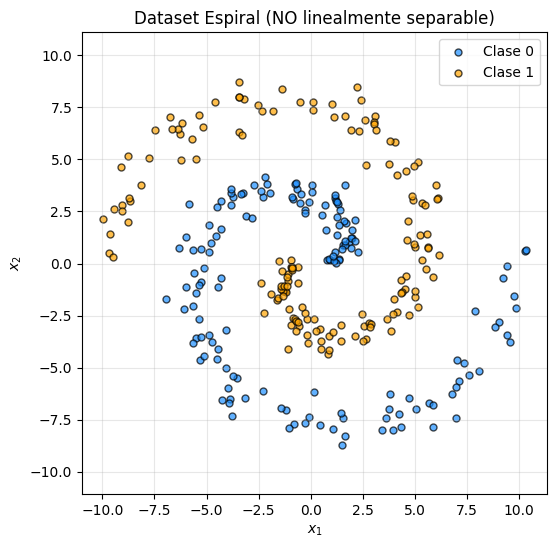

Tamaño: 300 muestras


In [59]:
def make_spiral(n_points=150, noise=0.5):
    """Genera dos espirales entrelazadas."""
    t0 = np.linspace(0, 2 * np.pi, n_points) + np.random.randn(n_points) * 0.2
    r0 = np.linspace(1, 10, n_points) + np.random.randn(n_points) * noise
    X0 = np.column_stack([r0 * np.cos(t0), r0 * np.sin(t0)])

    t1 = np.linspace(0, 2 * np.pi, n_points) + np.pi + np.random.randn(n_points) * 0.2
    r1 = np.linspace(1, 10, n_points) + np.random.randn(n_points) * noise
    X1 = np.column_stack([r1 * np.cos(t1), r1 * np.sin(t1)])

    X = np.vstack([X0, X1])
    y = np.concatenate([np.zeros(n_points), np.ones(n_points)])

    idx = np.random.permutation(len(y))
    return X[idx], y[idx]

np.random.seed(42)
X_spiral, y_spiral = make_spiral(150)

# Normalizar (importante para el entrenamiento)
X_mean = X_spiral.mean(axis=0)
X_std = X_spiral.std(axis=0)
X_spiral_norm = (X_spiral - X_mean) / X_std

# Visualizar
plt.figure(figsize=(6, 6))
plt.scatter(X_spiral[y_spiral == 0, 0], X_spiral[y_spiral == 0, 1],
            c='dodgerblue', label='Clase 0', s=25, edgecolors='k', alpha=0.7)
plt.scatter(X_spiral[y_spiral == 1, 0], X_spiral[y_spiral == 1, 1],
            c='orange', label='Clase 1', s=25, edgecolors='k', alpha=0.7)
plt.title('Dataset Espiral (NO linealmente separable)')
plt.xlabel('$x_1$')
plt.ylabel('$x_2$')
plt.legend()
plt.grid(True, alpha=0.3)
plt.axis('equal')
plt.show()

print(f"Tamaño: {len(y_spiral)} muestras")

### 2.2 Intentar con Perceptrón simple

In [61]:
print("=" * 55)
print("  Perceptrón simple intentando clasificar espiral...")
print("=" * 55)

model_spiral_fail = Perceptron(n_features=2, lr=0.5)
model_spiral_fail.train(X_spiral_norm, y_spiral, epochs=500)

  Perceptrón simple intentando clasificar espiral...
Epoch   0 | Loss: 0.6921 | Accuracy: 49.3%
Epoch  50 | Loss: 0.6326 | Accuracy: 50.7%
Epoch 100 | Loss: 0.6326 | Accuracy: 50.7%
Epoch 150 | Loss: 0.6326 | Accuracy: 50.7%
Epoch 200 | Loss: 0.6326 | Accuracy: 50.7%
Epoch 250 | Loss: 0.6326 | Accuracy: 50.7%
Epoch 300 | Loss: 0.6326 | Accuracy: 50.7%
Epoch 350 | Loss: 0.6326 | Accuracy: 50.7%
Epoch 400 | Loss: 0.6326 | Accuracy: 50.7%
Epoch 450 | Loss: 0.6326 | Accuracy: 50.7%

>>> Resultado final | Loss: 0.6326 | Accuracy: 50.7%


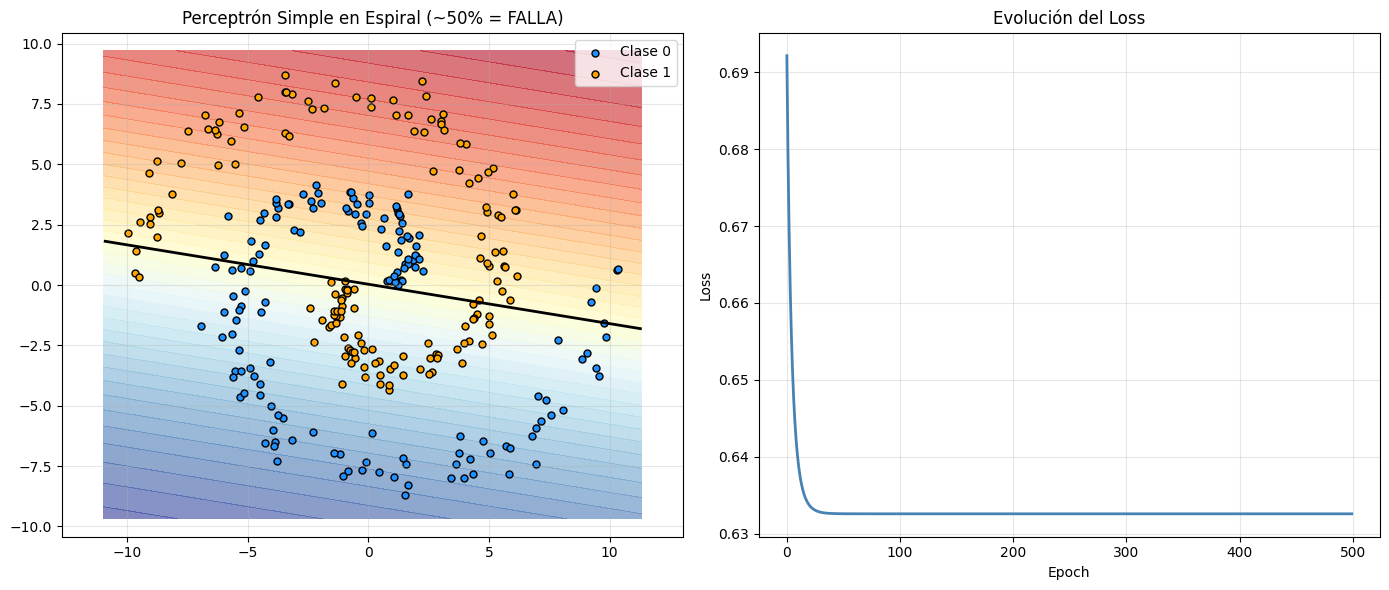

In [63]:
# Visualizar el intento fallido
def plot_decision_boundary_spiral(model, X, X_norm, y, title):
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    ax = axes[0]
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                          np.linspace(y_min, y_max, 300))
    grid = np.c_[xx.ravel(), yy.ravel()]
    grid_norm = (grid - X_mean) / X_std
    zz = model.predict(grid_norm).reshape(xx.shape)

    ax.contourf(xx, yy, zz, levels=50, cmap='RdYlBu_r', alpha=0.6)
    ax.contour(xx, yy, zz, levels=[0.5], colors='black', linewidths=2)
    ax.scatter(X[y == 0, 0], X[y == 0, 1], c='dodgerblue', edgecolors='k', s=25, label='Clase 0')
    ax.scatter(X[y == 1, 0], X[y == 1, 1], c='orange', edgecolors='k', s=25, label='Clase 1')
    ax.set_title(title)
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.axis('equal')

    axes[1].plot(model.losses, color='steelblue', linewidth=2)
    axes[1].set_title('Evolución del Loss')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

plot_decision_boundary_spiral(model_spiral_fail, X_spiral, X_spiral_norm, y_spiral,
                               "Perceptrón Simple en Espiral (~50% = FALLA)")

### ❌ Resultado
El perceptrón solo puede trazar una **línea recta**, pero el espiral requiere una frontera curva compleja.
El accuracy queda cerca del **50%**, que es lo mismo que adivinar al azar.

> **Conclusión:** Necesitamos más capas y funciones de activación no lineales → **Red Multicapa (MLP)**

---
## 3. Red Neuronal Multicapa (MLP) — Resolviendo el Espiral

Implementamos una red con **capas ocultas** y **ReLU** como activación.

**Arquitectura:** `2 → 32 → 16 → 1`

Componentes del entrenamiento:
1. **Forward propagation**: pasar datos capa por capa
2. **Calcular loss**: Binary Cross-Entropy
3. **Backpropagation**: calcular gradientes en sentido inverso (regla de la cadena)
4. **Update**: descenso de gradiente en todos los pesos

### 3.1 Implementar MLP desde cero

In [65]:
class MLP:
    """
    Red Neuronal Multicapa desde cero.
    Capas ocultas usan ReLU, capa de salida usa Sigmoid.
    """

    def __init__(self, layer_sizes, lr=0.01):
        """
        Args:
            layer_sizes: lista con neuronas por capa. Ej: [2, 32, 16, 1]
            lr: learning rate
        """
        self.lr = lr
        self.losses = []
        self.accuracies = []

        # Inicializar pesos con Xavier/He initialization
        self.weights = []
        self.biases = []
        for i in range(len(layer_sizes) - 1):
            scale = np.sqrt(2.0 / layer_sizes[i])  # He init (bueno para ReLU)
            W = np.random.randn(layer_sizes[i], layer_sizes[i + 1]) * scale
            b = np.zeros((1, layer_sizes[i + 1]))
            self.weights.append(W)
            self.biases.append(b)

        print(f"Red creada: {' → '.join(map(str, layer_sizes))}")
        total_params = sum(w.size + b.size for w, b in zip(self.weights, self.biases))
        print(f"Total de parámetros entrenables: {total_params}")

    # --- Funciones de activación ---
    def relu(self, z):
        return np.maximum(0, z)

    def relu_derivative(self, z):
        return (z > 0).astype(float)

    def sigmoid(self, z):
        z = np.clip(z, -500, 500)
        return 1 / (1 + np.exp(-z))

    # --- FORWARD PROPAGATION ---
    def forward(self, X):
        """Pasa los datos por cada capa de la red."""
        self.activations = [X]     # Guardamos para usar en backprop
        self.z_values = []

        current = X
        for i in range(len(self.weights)):
            # Transformación lineal: z = X·W + b
            z = current @ self.weights[i] + self.biases[i]
            self.z_values.append(z)

            if i == len(self.weights) - 1:
                # Última capa → Sigmoid (salida entre 0 y 1)
                current = self.sigmoid(z)
            else:
                # Capas ocultas → ReLU (no linealidad)
                current = self.relu(z)

            self.activations.append(current)

        return current

    # --- BACKPROPAGATION ---
    def backward(self, X, y):
        """Calcula gradientes y actualiza pesos (hacia atrás)."""
        m = len(y)
        y = y.reshape(-1, 1)
        output = self.activations[-1]

        # Gradiente inicial: derivada de BCE con sigmoid = (pred - y)
        delta = output - y

        # Recorrer capas en orden inverso
        for i in reversed(range(len(self.weights))):
            # Gradientes de pesos y bias
            dW = self.activations[i].T @ delta / m
            db = np.sum(delta, axis=0, keepdims=True) / m

            # Propagar error a la capa anterior (si no es la primera)
            if i > 0:
                delta = (delta @ self.weights[i].T) * self.relu_derivative(self.z_values[i - 1])

            # Actualizar parámetros (descenso de gradiente)
            self.weights[i] -= self.lr * dW
            self.biases[i] -= self.lr * db

    # --- ENTRENAMIENTO ---
    def train(self, X, y, epochs=3000, print_every=500):
        for epoch in range(epochs):
            # 1. Forward
            pred = self.forward(X)

            # 2. Calcular Loss (Binary Cross-Entropy)
            eps = 1e-8
            loss = -np.mean(
                y.reshape(-1, 1) * np.log(pred + eps) +
                (1 - y.reshape(-1, 1)) * np.log(1 - pred + eps)
            )
            self.losses.append(loss)

            acc = np.mean((pred.flatten() > 0.5) == y) * 100
            self.accuracies.append(acc)

            # 3. Backward + Update
            self.backward(X, y)

            if epoch % print_every == 0:
                print(f"Epoch {epoch:5d} | Loss: {loss:.4f} | Accuracy: {acc:.1f}%")

        # Final
        pred = self.forward(X)
        acc = np.mean((pred.flatten() > 0.5) == y) * 100
        print(f"\n>>> FINAL | Loss: {self.losses[-1]:.4f} | Accuracy: {acc:.1f}%")

    def predict(self, X):
        return self.forward(X).flatten()

### 3.2 Entrenar la MLP en el dataset espiral

In [73]:
np.random.seed(123)

# Arquitectura: 2 entradas → 32 ocultas → 16 ocultas → 1 salida
mlp = MLP(layer_sizes=[2, 32, 16, 1], lr=0.5)

print("\nEntrenando...")
print("-" * 55)
mlp.train(X_spiral_norm, y_spiral, epochs=400, print_every=100)

Red creada: 2 → 32 → 16 → 1
Total de parámetros entrenables: 641

Entrenando...
-------------------------------------------------------
Epoch     0 | Loss: 0.7520 | Accuracy: 48.3%
Epoch   100 | Loss: 0.0694 | Accuracy: 100.0%
Epoch   200 | Loss: 0.0165 | Accuracy: 100.0%
Epoch   300 | Loss: 0.0082 | Accuracy: 100.0%

>>> FINAL | Loss: 0.0053 | Accuracy: 100.0%


### 3.3 Visualizar la frontera de decisión del MLP

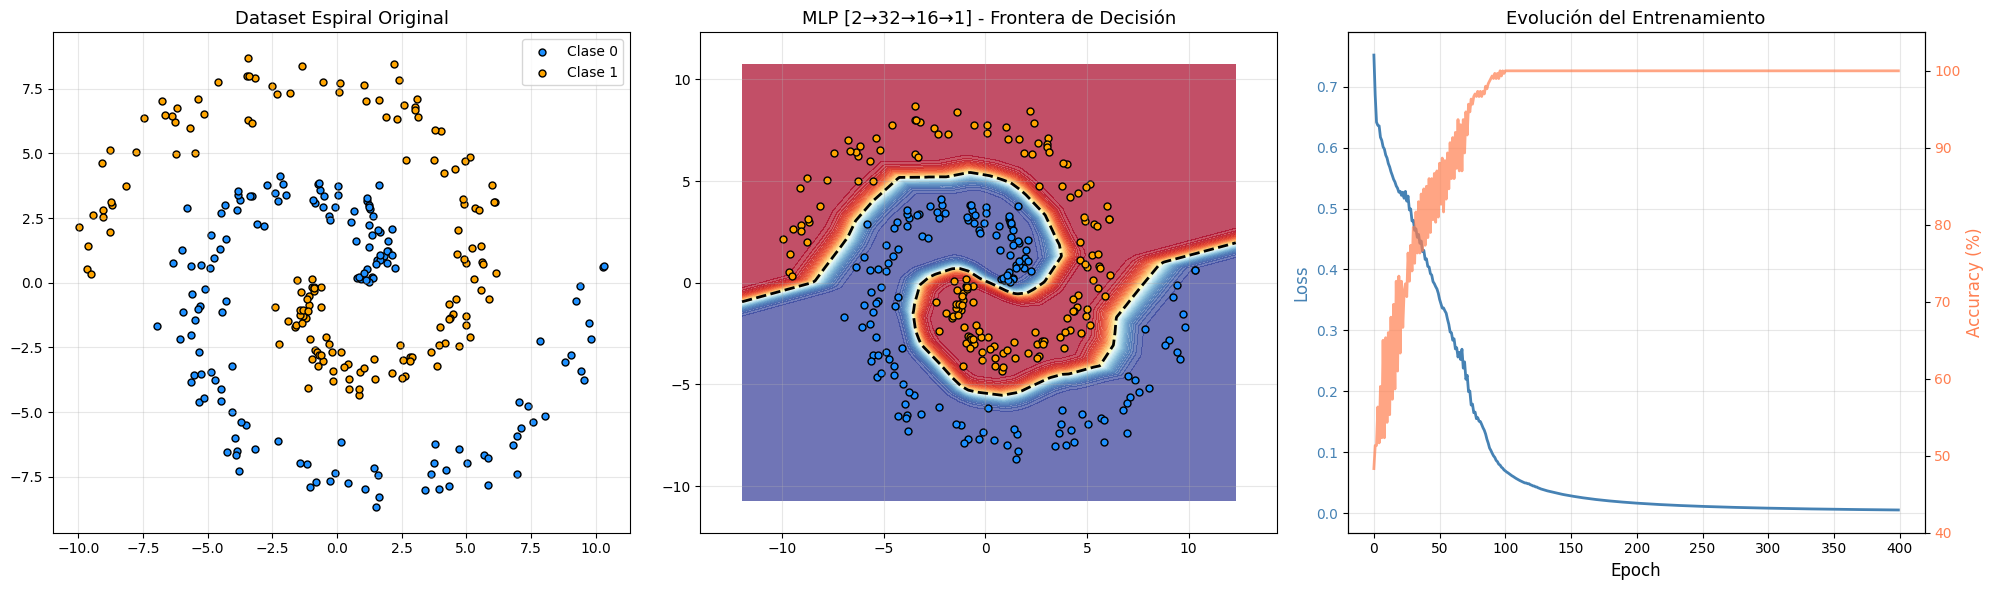

In [75]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# 1. Dataset original
ax = axes[0]
ax.scatter(X_spiral[y_spiral == 0, 0], X_spiral[y_spiral == 0, 1],
           c='dodgerblue', label='Clase 0', s=25, edgecolors='k')
ax.scatter(X_spiral[y_spiral == 1, 0], X_spiral[y_spiral == 1, 1],
           c='orange', label='Clase 1', s=25, edgecolors='k')
ax.set_title('Dataset Espiral Original', fontsize=13)
ax.legend()
ax.grid(True, alpha=0.3)
ax.axis('equal')

# 2. Frontera de decisión
ax = axes[1]
x_min, x_max = X_spiral[:, 0].min() - 2, X_spiral[:, 0].max() + 2
y_min, y_max = X_spiral[:, 1].min() - 2, X_spiral[:, 1].max() + 2
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 400),
                      np.linspace(y_min, y_max, 400))
grid = np.c_[xx.ravel(), yy.ravel()]
grid_norm = (grid - X_mean) / X_std
zz = mlp.predict(grid_norm).reshape(xx.shape)

ax.contourf(xx, yy, zz, levels=50, cmap='RdYlBu_r', alpha=0.7)
ax.contour(xx, yy, zz, levels=[0.5], colors='black', linewidths=2, linestyles='--')
ax.scatter(X_spiral[y_spiral == 0, 0], X_spiral[y_spiral == 0, 1],
           c='dodgerblue', edgecolors='k', s=25)
ax.scatter(X_spiral[y_spiral == 1, 0], X_spiral[y_spiral == 1, 1],
           c='orange', edgecolors='k', s=25)
ax.set_title('MLP [2→32→16→1] - Frontera de Decisión', fontsize=13)
ax.axis('equal')
ax.grid(True, alpha=0.3)

# 3. Loss y Accuracy
ax1 = axes[2]
color1 = 'steelblue'
ax1.plot(mlp.losses, color=color1, linewidth=2, label='Loss')
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Loss', color=color1, fontsize=12)
ax1.tick_params(axis='y', labelcolor=color1)

ax2 = ax1.twinx()
color2 = 'coral'
ax2.plot(mlp.accuracies, color=color2, linewidth=2, alpha=0.7, label='Accuracy')
ax2.set_ylabel('Accuracy (%)', color=color2, fontsize=12)
ax2.tick_params(axis='y', labelcolor=color2)
ax2.set_ylim(40, 105)

ax1.set_title('Evolución del Entrenamiento', fontsize=13)
ax1.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### ✅ Resultado
El MLP aprende una frontera de decisión **curva y compleja** que se adapta a la forma del espiral.

Esto es posible gracias a:
- **Múltiples neuronas** por capa (conocimiento especializado)
- **Múltiples capas** (conocimiento jerárquico)
- **ReLU** como función de activación (rompe la linealidad)
- **Backpropagation** para ajustar todos los pesos

---
## 4. Comparación: Perceptrón vs MLP

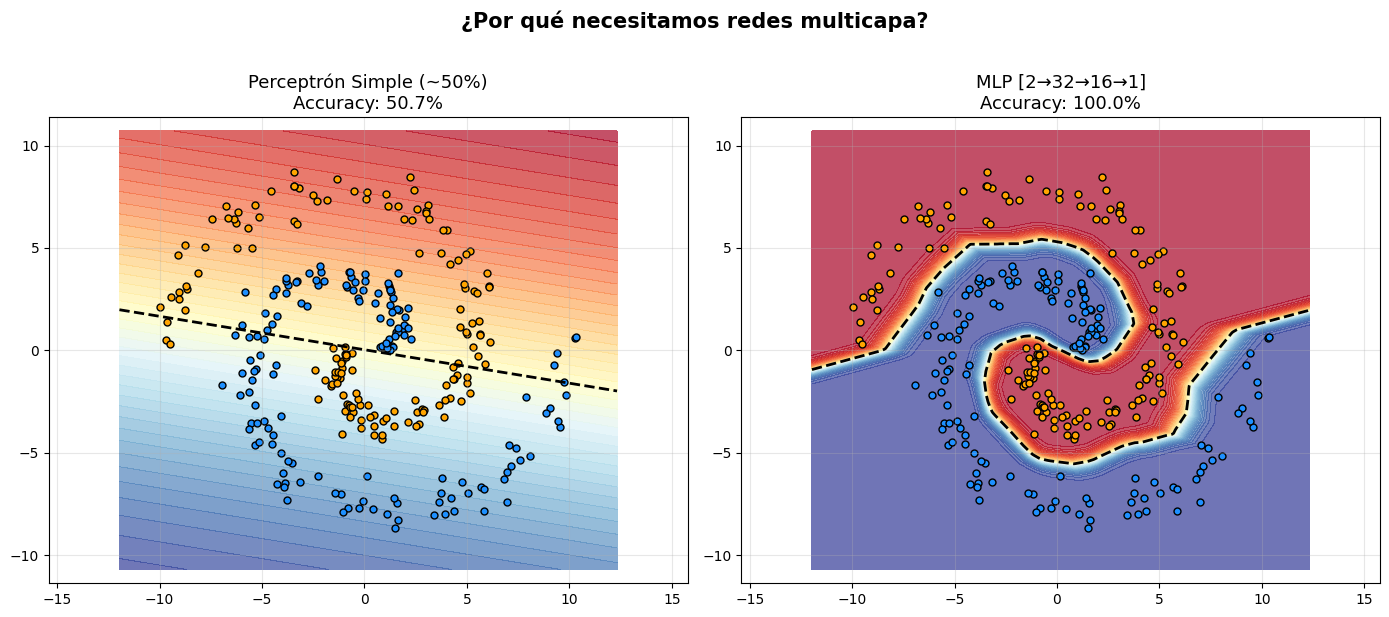

In [77]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

x_min, x_max = X_spiral[:, 0].min() - 2, X_spiral[:, 0].max() + 2
y_min, y_max = X_spiral[:, 1].min() - 2, X_spiral[:, 1].max() + 2
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 400),
                      np.linspace(y_min, y_max, 400))
grid = np.c_[xx.ravel(), yy.ravel()]
grid_norm = (grid - X_mean) / X_std

models = [
    (model_spiral_fail, "Perceptrón Simple (~50%)"),
    (mlp, "MLP [2→32→16→1]")
]

for ax, (model, title) in zip(axes, models):
    zz = model.predict(grid_norm).reshape(xx.shape)
    ax.contourf(xx, yy, zz, levels=50, cmap='RdYlBu_r', alpha=0.7)
    ax.contour(xx, yy, zz, levels=[0.5], colors='black', linewidths=2, linestyles='--')
    ax.scatter(X_spiral[y_spiral == 0, 0], X_spiral[y_spiral == 0, 1],
               c='dodgerblue', edgecolors='k', s=25)
    ax.scatter(X_spiral[y_spiral == 1, 0], X_spiral[y_spiral == 1, 1],
               c='orange', edgecolors='k', s=25)

    pred = model.predict(X_spiral_norm)
    acc = np.mean((pred > 0.5) == y_spiral) * 100
    ax.set_title(f"{title}\nAccuracy: {acc:.1f}%", fontsize=13)
    ax.axis('equal')
    ax.grid(True, alpha=0.3)

plt.suptitle('¿Por qué necesitamos redes multicapa?', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 5. Experimenta tú mismo

Modifica los parámetros y observa qué sucede:
- **Learning rate**: ¿qué pasa si es muy grande (10) o muy pequeño (0.001)?
- **Arquitectura**: prueba `[2, 4, 1]` vs `[2, 64, 32, 1]`
- **Épocas**: ¿cuántas necesita para converger?

Red creada: 2 → 16 → 8 → 1
Total de parámetros entrenables: 193
Epoch     0 | Loss: 0.9501 | Accuracy: 52.3%
Epoch   600 | Loss: 0.0046 | Accuracy: 100.0%
Epoch  1200 | Loss: 0.0016 | Accuracy: 100.0%
Epoch  1800 | Loss: 0.0009 | Accuracy: 100.0%
Epoch  2400 | Loss: 0.0006 | Accuracy: 100.0%

>>> FINAL | Loss: 0.0004 | Accuracy: 100.0%


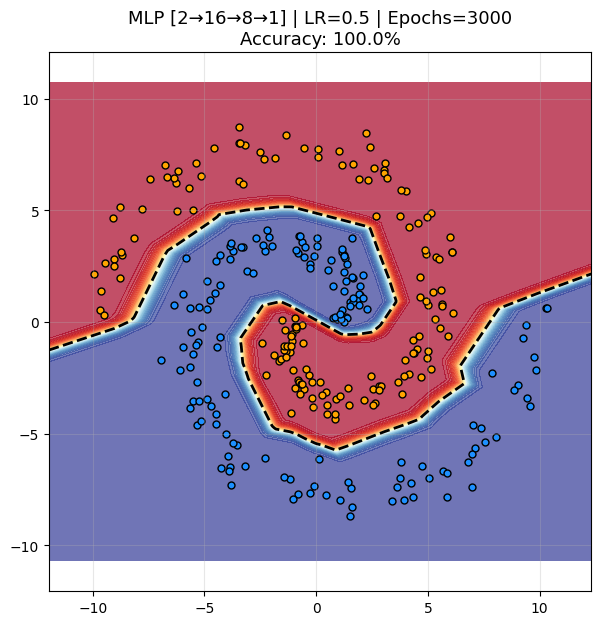

In [40]:
# ============================================
# MODIFICA ESTOS VALORES Y OBSERVA EL CAMBIO
# ============================================

ARQUITECTURA = [2, 16, 8, 1]    # Prueba: [2, 4, 1] o [2, 64, 32, 16, 1]
LEARNING_RATE = 0.5              # Prueba: 0.001, 0.1, 1.0, 5.0
EPOCHS = 3000                    # Prueba: 500, 1000, 5000

# ============================================

np.random.seed(99)
mlp_exp = MLP(layer_sizes=ARQUITECTURA, lr=LEARNING_RATE)
mlp_exp.train(X_spiral_norm, y_spiral, epochs=EPOCHS, print_every=EPOCHS//5)

# Visualizar
fig, ax = plt.subplots(1, 1, figsize=(7, 7))
zz = mlp_exp.predict(grid_norm).reshape(xx.shape)
ax.contourf(xx, yy, zz, levels=50, cmap='RdYlBu_r', alpha=0.7)
ax.contour(xx, yy, zz, levels=[0.5], colors='black', linewidths=2, linestyles='--')
ax.scatter(X_spiral[y_spiral == 0, 0], X_spiral[y_spiral == 0, 1],
           c='dodgerblue', edgecolors='k', s=25)
ax.scatter(X_spiral[y_spiral == 1, 0], X_spiral[y_spiral == 1, 1],
           c='orange', edgecolors='k', s=25)

pred = mlp_exp.predict(X_spiral_norm)
acc = np.mean((pred > 0.5) == y_spiral) * 100
arch_str = '→'.join(map(str, ARQUITECTURA))
ax.set_title(f"MLP [{arch_str}] | LR={LEARNING_RATE} | Epochs={EPOCHS}\nAccuracy: {acc:.1f}%", fontsize=13)
ax.axis('equal')
ax.grid(True, alpha=0.3)
plt.show()

---
## 6. Efecto del Learning Rate

Visualización de cómo el learning rate afecta la convergencia.

Red creada: 2 → 16 → 8 → 1
Total de parámetros entrenables: 193
Epoch     0 | Loss: 0.9142 | Accuracy: 49.0%

>>> FINAL | Loss: 0.5103 | Accuracy: 73.7%
Red creada: 2 → 16 → 8 → 1
Total de parámetros entrenables: 193
Epoch     0 | Loss: 0.9142 | Accuracy: 49.0%

>>> FINAL | Loss: 0.0114 | Accuracy: 100.0%
Red creada: 2 → 16 → 8 → 1
Total de parámetros entrenables: 193
Epoch     0 | Loss: 0.9142 | Accuracy: 49.0%

>>> FINAL | Loss: 0.0004 | Accuracy: 100.0%
Red creada: 2 → 16 → 8 → 1
Total de parámetros entrenables: 193
Epoch     0 | Loss: 0.9142 | Accuracy: 49.0%

>>> FINAL | Loss: 0.6931 | Accuracy: 50.0%


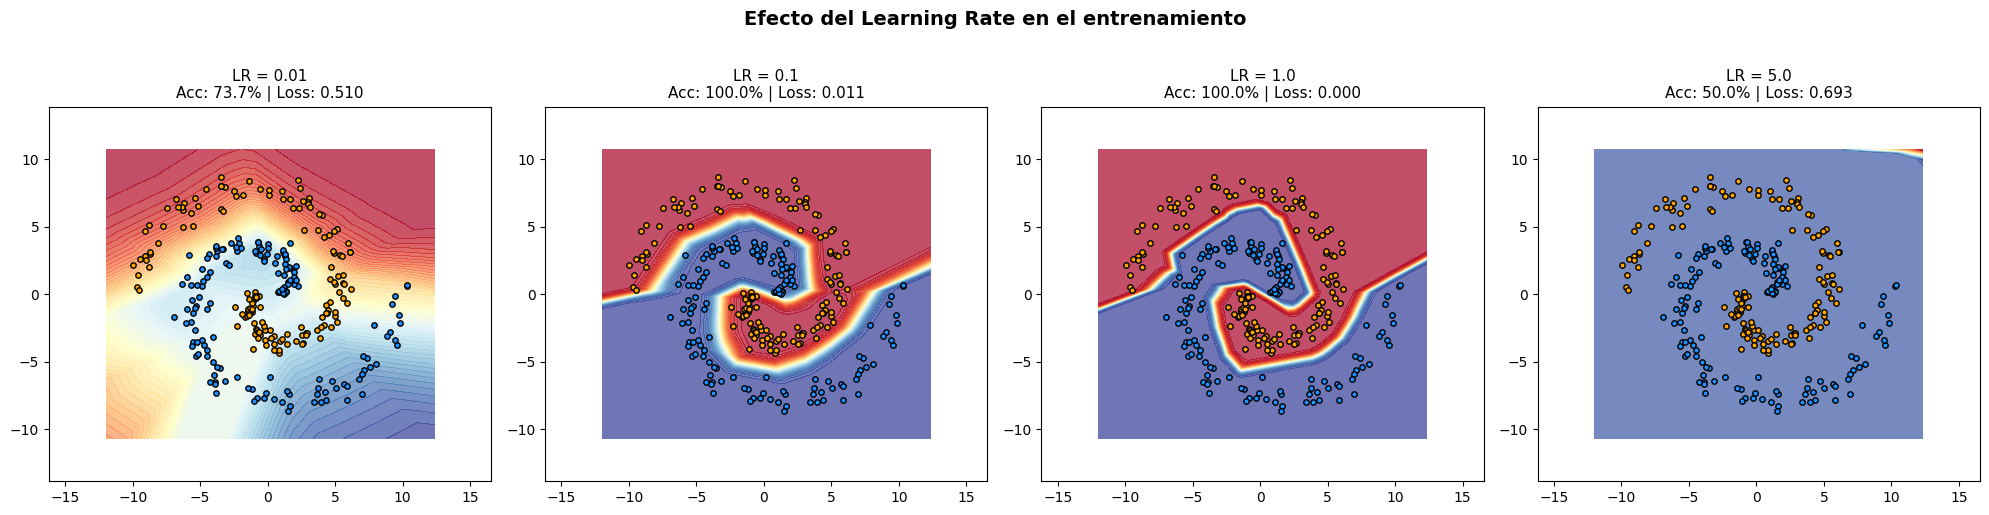

In [43]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

learning_rates = [0.01, 0.1, 1.0, 5.0]

for ax, lr in zip(axes, learning_rates):
    np.random.seed(42)
    m = MLP(layer_sizes=[2, 16, 8, 1], lr=lr)
    m.train(X_spiral_norm, y_spiral, epochs=2000, print_every=99999)  # silencioso

    zz = m.predict(grid_norm).reshape(xx.shape)
    ax.contourf(xx, yy, zz, levels=50, cmap='RdYlBu_r', alpha=0.7)
    ax.scatter(X_spiral[y_spiral == 0, 0], X_spiral[y_spiral == 0, 1],
               c='dodgerblue', edgecolors='k', s=15)
    ax.scatter(X_spiral[y_spiral == 1, 0], X_spiral[y_spiral == 1, 1],
               c='orange', edgecolors='k', s=15)

    pred = m.predict(X_spiral_norm)
    acc = np.mean((pred > 0.5) == y_spiral) * 100
    ax.set_title(f"LR = {lr}\nAcc: {acc:.1f}% | Loss: {m.losses[-1]:.3f}", fontsize=11)
    ax.axis('equal')

plt.suptitle('Efecto del Learning Rate en el entrenamiento', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## Resumen

| Concepto | Qué hace | En el código |
|---|---|---|
| **Neurona** | $f(x) = \sigma(Xw + b)$ | `predict()` |
| **Función de activación** | Introduce no-linealidad | `sigmoid()`, `relu()` |
| **Función de coste** | Mide qué tan mal está el modelo | Binary Cross-Entropy en `train()` |
| **Gradiente** | Dirección de mayor cambio | `backward()` |
| **Descenso de gradiente** | Actualiza pesos para reducir error | `w -= lr * dw` |
| **Backpropagation** | Propaga el error hacia atrás | `backward()` con regla de la cadena |
| **Learning rate** | Tamaño del paso en cada actualización | `self.lr` |